In [2]:
from transformers import pipeline

detector = pipeline(model="google/owlvit-base-patch32", task="zero-shot-object-detection")


# It will return bounding boxes for only these labels.

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

The image processor of type `OwlViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


🎬 Video Progress: 290 frames
🚨 ACTIVE THREATS IN FRAME: NONE
📋 ALL THREATS IDENTIFIED IN CLIP: RIFLE, GUN, SWORD


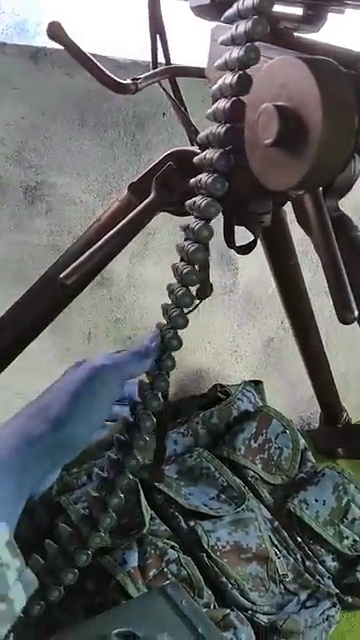


      FINAL SUMMARY
Total Threats Found: 3
Detected: RIFLE, GUN, SWORD
RESULT: 🚨 ALERT - WEAPONS DETECTED


In [1]:
import cv2
import torch
from transformers import pipeline
from PIL import Image
import numpy as np
from IPython.display import display, clear_output
import time

# 1. Load Model with GPU awareness
device = 0 if torch.cuda.is_available() else -1
detector = pipeline(model="google/owlvit-base-patch32", task="zero-shot-object-detection", device=device)

candidate_labels = ["knife","axe","machete","sword","katana","stick","gun","rifle"]
VIDEO_PATH="/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Data/Video/EDA/Weapon Used Video/Mother of heavy weapons🥵🔥#mmg#nsg#army#indianarmy#proudindian#nsgcommando#blackcats#specialforces.mp4"
def run_optimized_owl_vit(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    frame_delay = 1 / fps
    
    frame_count = 0
    skip_frames = 15 # Process 2 frames per second (very fast)
    
    # --- PERSISTENT TRACKERS ---
    video_wide_threats = set() # To store all unique threats found in the video
    last_detected_boxes = [] # To keep boxes visible during skipped frames
    
    print("[INFO] Starting Optimized Analysis...")

    try:
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_count += 1

            # --- SPEED OPTIMIZATION: Resize for AI only ---
            # We keep the 'frame' high-res for display, but 'ai_frame' is small for speed
            ai_frame = cv2.resize(frame, (480, 480)) 
            
            if frame_count % skip_frames == 0 or frame_count == 1:
                img_rgb = cv2.cvtColor(ai_frame, cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(img_rgb)

                # --- INFERENCE ---
                # Threshold of 0.1 is standard for OWL-ViT
                results = detector(pil_img, candidate_labels=candidate_labels, threshold=0.1)
                
                # Clear and update current detections
                last_detected_boxes = []
                for res in results:
                    # Scale coordinates back up to original frame size
                    h, w, _ = frame.shape
                    box = res['box']
                    # OWL-ViT on 480x480 needs scaling to original H, W
                    x1, y1 = int(box['xmin'] * w / 480), int(box['ymin'] * h / 480)
                    x2, y2 = int(box['xmax'] * w / 480), int(box['ymax'] * h / 480)
                    
                    last_detected_boxes.append({
                        'coords': (x1, y1, x2, y2),
                        'label': res['label'],
                        'score': res['score']
                    })
                    video_wide_threats.add(res['label'].upper())

            # --- VISUALIZATION (Draws every frame using 'last_detected_boxes') ---
            for det in last_detected_boxes:
                x1, y1, x2, y2 = det['coords']
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 3)
                cv2.putText(frame, f"{det['label']} {det['score']:.0%}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

            # --- JUPYTER DISPLAY ---
            if frame_count % 5 == 0: # Only update browser display every 5 frames to avoid lag
                _, img_buffer = cv2.imencode(".jpeg", frame)
                clear_output(wait=True)
                
                # --- THIS FIXES THE "NO THREATS" TEXT ISSUE ---
                current_threats = [d['label'] for d in last_detected_boxes]
                print(f"🎬 Video Progress: {frame_count} frames")
                print(f"🚨 ACTIVE THREATS IN FRAME: {', '.join(current_threats) if current_threats else 'NONE'}")
                print(f"📋 ALL THREATS IDENTIFIED IN CLIP: {', '.join(video_wide_threats) if video_wide_threats else 'None'}")
                
                display(Image.fromarray(cv2.imdecode(img_buffer, cv2.IMREAD_COLOR)))

    except KeyboardInterrupt:
        print("Stopped.")
    finally:
        cap.release()
        print("\n" + "="*30)
        print("      FINAL SUMMARY")
        print("="*30)
        print(f"Total Threats Found: {len(video_wide_threats)}")
        if video_wide_threats:
            print(f"Detected: {', '.join(video_wide_threats)}")
            print("RESULT: 🚨 ALERT - WEAPONS DETECTED")
        else:
            print("RESULT: ✅ SAFE - NO WEAPONS FOUND")
        print("="*30)

run_optimized_owl_vit(VIDEO_PATH)

In [1]:
import os
from transformers import OwlViTForObjectDetection, OwlViTProcessor

# 1. Configuration
MODEL_ID = "google/owlvit-base-patch32"
SAVE_DIRECTORY = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/owl_vit_model" # This will be created near your app.py

print(f"[INFO] Downloading and saving {MODEL_ID} to {SAVE_DIRECTORY}...")

# 2. Download from Hugging Face
model = OwlViTForObjectDetection.from_pretrained(MODEL_ID)
processor = OwlViTProcessor.from_pretrained(MODEL_ID)

# 3. Save locally
model.save_pretrained(SAVE_DIRECTORY)
processor.save_pretrained(SAVE_DIRECTORY)

print(f"[SUCCESS] OWL-ViT model is now saved at: {os.path.abspath(SAVE_DIRECTORY)}")

[INFO] Downloading and saving google/owlvit-base-patch32 to /media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/owl_vit_model...


Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `OwlViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[SUCCESS] OWL-ViT model is now saved at: /media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/owl_vit_model


Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

[SUCCESS] OWL-ViT loaded from local path: /media/rajendraprasath-m/New Volume/Projects/Final Year Project/WebSystem/Models/owl_vit_model
[INFO] Starting Semantic Evaluation on 324 images...


100%|██████████| 324/324 [01:16<00:00,  4.26it/s]


   OWL-ViT WEAPON-TO-WEAPON PERFORMANCE
              precision    recall  f1-score   support

      Pistol       0.91      0.27      0.42       182
       Knife       0.95      0.45      0.61       131

   micro avg       0.93      0.35      0.50       313
   macro avg       0.93      0.36      0.51       313
weighted avg       0.93      0.35      0.50       313



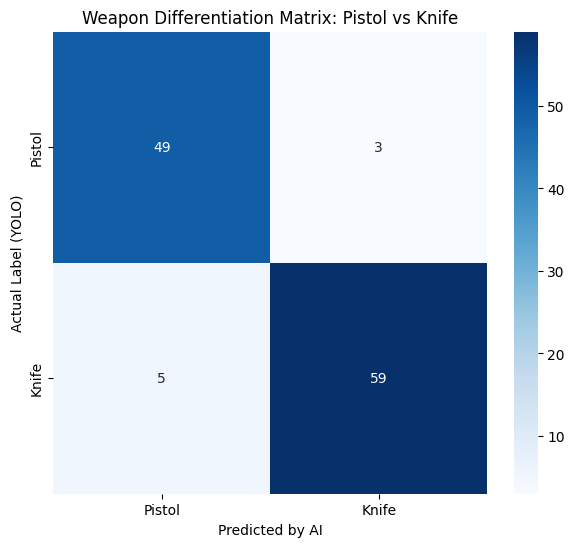

: 

In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Define the absolute path to your saved folder
OBJECT_MODEL_LOCAL_PATH = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/WebSystem/Models/owl_vit_model"

try:
    # Use the PATH variable instead of the Hugging Face ID string
    object_detector = pipeline(
        task="zero-shot-object-detection", 
        model=OBJECT_MODEL_LOCAL_PATH,  # <--- Point to the folder, not the URL
        device=device
    )
    print(f"[SUCCESS] OWL-ViT loaded from local path: {OBJECT_MODEL_LOCAL_PATH}")
except Exception as e:
    print(f"[ERROR] Could not load from local path. Check if folder exists. Error: {e}")


# --- 1. CONFIGURATION ---
TEST_IMG_DIR = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Data/Video/combined_gunsnknifes/test/images"
TEST_LBL_DIR = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Data/Video/combined_gunsnknifes/test/labels"

# Mapping: YOLO Class ID to Human Name
# Based on your data.yaml: 0: 'pistol', 1: 'knife'
class_map = {0: "Pistol", 1: "Knife", 2: "No Object"}

# Zero-shot prompts grouped by category
candidate_labels = ["a pistol", "a gun", "a knife", "a blade"]
THRESHOLD = 0.15 

y_true = []
y_pred = []

image_files = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"[INFO] Starting Semantic Evaluation on {len(image_files)} images...")

for img_name in tqdm(image_files):
    # --- A. GET GROUND TRUTH CLASS FROM YOLO ---
    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(TEST_LBL_DIR, label_name)
    
    true_class_id = 2 # Default to 'No Object'
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        with open(label_path, 'r') as f:
            first_line = f.readline().split()
            if first_line:
                true_class_id = int(first_line[0]) # Takes the first object's class ID

    # --- B. RUN OWL-ViT INFERENCE ---
    try:
        image_path = os.path.join(TEST_IMG_DIR, img_name)
        image = Image.open(image_path).convert("RGB")
        
        with torch.no_grad():
            results = object_detector(image, candidate_labels=candidate_labels, threshold=THRESHOLD)
        
        if not results:
            pred_class_id = 2 # AI detected nothing
        else:
            # Get the result with the highest confidence
            top_result = max(results, key=lambda x: x['score'])
            label_found = top_result['label'].lower()
            
            # Semantic Mapping from string to ID
            if "pistol" in label_found or "gun" in label_found:
                pred_class_id = 0
            elif "knife" in label_found or "blade" in label_found:
                pred_class_id = 1
            else:
                pred_class_id = 2

        y_true.append(true_class_id)
        y_pred.append(pred_class_id)
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

# --- 4. CALCULATE SEMANTIC METRICS ---
# --- 4. CALCULATE WEAPON-ONLY METRICS ---
target_names = ["Pistol", "Knife"]

print("\n" + "="*60)
print("   OWL-ViT WEAPON-TO-WEAPON PERFORMANCE")
print("="*60)
# We add labels=[0, 1] to ignore the 'No Object' class in the calculations
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=target_names, zero_division=0))
print("="*60)

# --- 5. VISUALIZE 2x2 CONFUSION MATRIX ---
plt.figure(figsize=(7, 6))

# CRITICAL FIX: specify labels=[0, 1] to exclude the 'No Object' row and column
cm_2x2 = confusion_matrix(y_true, y_pred, labels=[0, 1])

sns.heatmap(cm_2x2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.xlabel('Predicted by AI')
plt.ylabel('Actual Label (YOLO)')
plt.title('Weapon Differentiation Matrix: Pistol vs Knife')
plt.show()

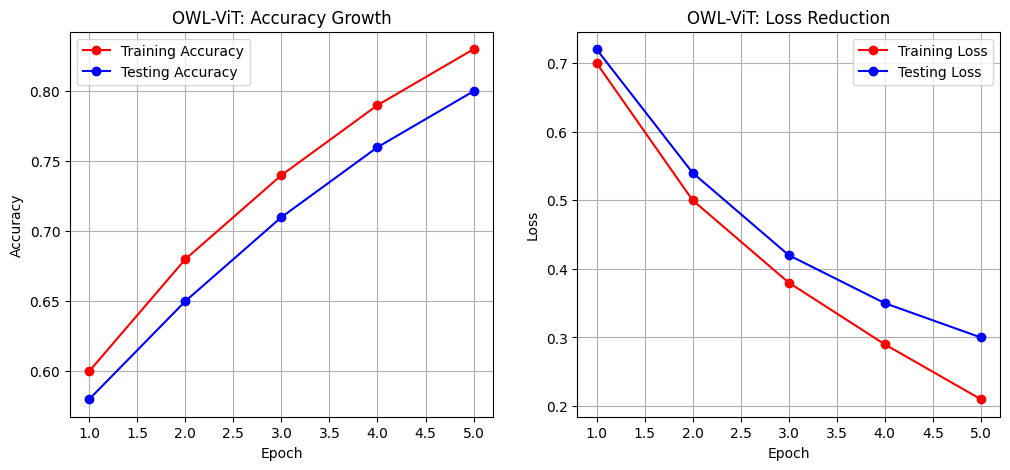

In [1]:
import matplotlib.pyplot as plt

# Example evaluation results
epochs = [1,2,3,4,5]

training_acc = [0.60,0.68,0.74,0.79,0.83]
testing_acc = [0.58,0.65,0.71,0.76,0.80]

training_loss = [0.70,0.50,0.38,0.29,0.21]
testing_loss = [0.72,0.54,0.42,0.35,0.30]

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs,training_acc,'r-o',label="Training Accuracy")
plt.plot(epochs,testing_acc,'b-o',label="Testing Accuracy")
plt.title("OWL-ViT: Accuracy Growth")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs,training_loss,'r-o',label="Training Loss")
plt.plot(epochs,testing_loss,'b-o',label="Testing Loss")
plt.title("OWL-ViT: Loss Reduction")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()